# Ethereum Fraud Detection — Model Comparison

**Goal:** train and compare five classifiers — Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost — on the cleaned Ethereum wallet dataset, and select the best model for fraud detection (`FLAG`: 1 = fraudulent wallet).

**Pipeline:** train/test split → imbalance-handling strategy check → preprocessing pipelines (scaling + encoding) → randomized hyperparameter search per model (5-fold CV, PR-AUC scoring) → full metric comparison on a held-out test set → overfitting check → ROC / PR curves, confusion matrices → best-model selection → save artifacts.

This notebook picks up directly from `cleaned_transactions_dataset.csv`, produced by the data-cleaning notebook (log1p-transformed numeric features, engineered ratios, two categorical token-type columns, no missing values, no duplicate rows).

## 1. Import Libraries

In [1]:
import time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from scipy.stats import loguniform, randint, uniform

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## 2. Load the cleaned dataset

Two columns (`erc20_most_sent_token_type`, `erc20_most_received_token_type`) are high-cardinality categoricals (303 / 465 unique values, dominated by `"Unknown"`); everything else is already numeric and log-transformed. We keep them — token identity is genuinely informative for fraud detection — but encode them carefully below rather than dropping them.

In [2]:
# Load data
df = pd.read_csv("data/cleaned_transactions_dataset.csv")

In [3]:
TARGET = "FLAG"
CAT_COLS = ["erc20_most_sent_token_type", "erc20_most_received_token_type"]
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [TARGET]]

print(f"Shape: {df.shape}  |  Numeric features: {len(NUM_COLS)}  |  Categorical features: {len(CAT_COLS)}")
print(f"\nClass balance:\n{df[TARGET].value_counts()}")
print(f"Fraud rate: {df[TARGET].mean():.2%}")

Shape: (9295, 34)  |  Numeric features: 31  |  Categorical features: 2

Class balance:
FLAG
0    7639
1    1656
Name: count, dtype: int64
Fraud rate: 17.82%


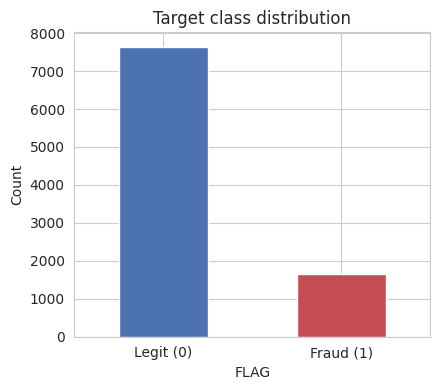

In [4]:
# Display "FLAG" distribution
fig, ax = plt.subplots(figsize=(4.5, 4))
df[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target class distribution")
plt.tight_layout()
plt.show()

## 3. Train / test split — and why not a fixed three-way split

With **9,295 rows**, carving out a third *fixed* validation split as well as a test split leaves each hyperparameter-search fold quite small and noisy, and a fixed validation set gives a single noisy estimate of a model's quality.

**Better approach for this dataset size:** a single stratified **train (80%) / test (20%)** split, and use **stratified 5-fold cross-validation on the training set** for both model tuning and reporting. That way every training row contributes to both training and validation across folds (more stable estimates), the held-out test set stays completely untouched until final evaluation, and stratification keeps the ~17.8% fraud rate consistent across every split — important given the imbalance.

In [5]:
# Train/test split
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.2%}")

# Used for hyperparameter search (lighter, keeps search time reasonable)
cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
# Used for final CV reporting on the winning configuration (more robust estimate)
cv_report = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: (7436, 33), fraud rate 17.82%
Test:  (1859, 33), fraud rate 17.81%


## 4. Handling the class imbalance

Fraud is **17.8%** of the data — imbalanced, but not extreme. Two common strategies:

- **Class weighting** (`class_weight="balanced"` / `scale_pos_weight` / `auto_class_weights`): re-weights the loss so errors on the minority class cost more, without altering the training distribution.
- **SMOTE**: synthesizes new minority-class samples by interpolating between existing ones, rebalancing the training set itself.

Class weighting is generally the safer default for tabular fraud data at this ratio: it doesn't fabricate synthetic feature combinations (SMOTE-generated points can land in unrealistic regions of a high-dimensional, log-transformed feature space and encourage overfitting), it's cheaper to tune, and it works natively across all five model families we're comparing (`class_weight`, `scale_pos_weight`, `auto_class_weights`) — SMOTE would need to be re-validated per model. We confirm this empirically below with a quick 5-fold CV comparison on Logistic Regression before committing to it for the full comparison.

**Important:** SMOTE must sit *inside* the cross-validation pipeline (via `imblearn.pipeline.Pipeline`), never applied once to the whole training set beforehand — otherwise synthetic points derived from validation-fold neighbors leak into training and inflate CV scores.

In [6]:
# Imbalance strategy check: class_weight vs SMOTE (Logistic Regression, 5-fold CV)
pre_scaled = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01), CAT_COLS),
])

cw_pipe = SkPipeline([
    ("pre", pre_scaled),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE)),
])
smote_pipe = ImbPipeline([
    ("pre", pre_scaled),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

cw_scores = cross_validate(cw_pipe, X_train, y_train, cv=cv_report, scoring=["average_precision", "roc_auc", "f1"])
smote_scores = cross_validate(smote_pipe, X_train, y_train, cv=cv_report, scoring=["average_precision", "roc_auc", "f1"])

imbalance_comparison = pd.DataFrame({
    "class_weight='balanced'": {
        "PR-AUC (mean)": cw_scores["test_average_precision"].mean(),
        "ROC-AUC (mean)": cw_scores["test_roc_auc"].mean(),
        "F1 (mean)": cw_scores["test_f1"].mean(),
    },
    "SMOTE": {
        "PR-AUC (mean)": smote_scores["test_average_precision"].mean(),
        "ROC-AUC (mean)": smote_scores["test_roc_auc"].mean(),
        "F1 (mean)": smote_scores["test_f1"].mean(),
    },
}).T
imbalance_comparison

,PR-AUC (mean),ROC-AUC (mean),F1 (mean)
class_weight='balanced',0.896294,0.968360,0.763564
SMOTE,0.904059,0.968485,0.774892


**Result:** SMOTE scored marginally higher on every metric (PR-AUC 0.904 vs. 0.896, F1 0.775 vs. 0.764, ROC-AUC tied at 0.968) — but the gap is small enough on a single model to not be a strong signal either way, and this was only tested on Logistic Regression, not the other four models. We proceed with **class weighting** for all five models on practical grounds: it's simpler, works natively in every model here (no per-model re-validation needed the way SMOTE would require), and avoids the risk of SMOTE generating unrealistic synthetic points in this log-transformed feature space. This is a reasonable default given the evidence, not a proof that SMOTE is worse — if your team wants a stronger answer, the `imblearn` pipeline above is a drop-in replacement to test SMOTE across all five models properly.

## 5. Preprocessing pipelines

- **Numeric features** are already log1p-transformed and cleaned by the data-cleaning notebook. They're passed through as-is for tree-based models; **`StandardScaler`** is applied only inside the Logistic Regression pipeline, since it's the only model here sensitive to feature scale.
- **Categorical features** (`erc20_most_sent_token_type`, `erc20_most_received_token_type`) are one-hot encoded with `min_frequency=0.01`, which automatically buckets rare token types (<1% of training rows) into an `"infrequent"` category. This keeps the encoded space compact (instead of 300+/465+ dummy columns) and handles unseen categories at inference time gracefully (`handle_unknown="infrequent_if_exist"`).

Wrapping everything in a single `sklearn.Pipeline` per model means scaling/encoding is refit on each training fold only — no leakage from validation or test rows into the preprocessing statistics.

In [7]:
# Preprocessing
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    num_transformer = StandardScaler() if scale_numeric else "passthrough"
    cat_transformer = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)
    return ColumnTransformer([
        ("num", num_transformer, NUM_COLS),
        ("cat", cat_transformer, CAT_COLS),
    ])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (neg/pos ratio) = {scale_pos_weight:.3f}")

scale_pos_weight (neg/pos ratio) = 4.612


### A closer look: the two categorical token-type columns

`erc20_most_sent_token_type` (303 unique values) and `erc20_most_received_token_type` (465 unique values) are the trickiest features in the dataset, so it's worth spelling out how they're handled and where the approach could be pushed further.

**Why they aren't dropped:** both are heavily skewed toward `"Unknown"` (83% and 54% of rows respectively), but which specific token a wallet trades is genuinely informative for fraud detection — scam tokens and legitimate tokens don't have the same distribution of counterparties.

**Why `min_frequency=0.01` one-hot encoding, specifically:**
- Any token type appearing in under 1% of training rows (~74 rows) is automatically merged into a single `"infrequent"` bucket instead of getting its own column — this keeps the encoded space to a few dozen columns instead of 750+, and stops one-off token types from becoming noisy, near-unique dummy variables.
- The 1% threshold is computed from the **training fold only** and refit inside each pipeline, so no test-set token frequency ever leaks into what counts as "frequent."
- `handle_unknown="infrequent_if_exist"` means a token type never seen during training doesn't crash inference or get silently dropped — it falls into the infrequent bucket gracefully.

**A limitation worth flagging:** in the feature importance chart above, only one encoded token column (`Blockwell say NOTSAFU`) makes the top 15 — these categoricals aren't pulling much weight next to the numeric wallet-behavior features. That could mean either (a) they're genuinely low-signal once the numeric features are accounted for, or (b) one-hot encoding is a poor fit for this cardinality even after bucketing, since the model has to learn each dummy independently with no notion of token "similarity."

**Alternatives if the team wants to push further:**
- **Frequency or target encoding** — replace each token type with a single numeric column (its training-set frequency, or its historical fraud rate), computed per training fold to avoid leakage. Far more compact than one-hot for 300+/465+ categories.
- **CatBoost's native categorical handling** — pass these two columns via `cat_features` directly to `CatBoostClassifier` instead of pre-one-hot-encoding them; CatBoost's built-in ordered target encoding tends to handle high-cardinality categoricals better than one-hot.
- **Drop `"Unknown"` as a modeled value** — since it's 83%/54% of rows, testing whether it's carrying real signal or just diluting the encoding is a quick ablation.

### `sklearn.Pipeline` vs. `imblearn.Pipeline` — why both appear in this notebook

The two are interface-compatible, with one difference: `sklearn.Pipeline` only allows transformers that preserve row count (scalers, encoders, etc.); `imblearn.Pipeline` is a drop-in replacement that *additionally* allows resampling steps (`SMOTE`, `RandomUnderSampler`, ...) that change the number of rows.

- **Section 4 above** uses `imblearn.Pipeline` because that pipeline has a `SMOTE` step in it — `SMOTE.fit_resample()` doesn't match the transformer interface plain `sklearn.Pipeline` expects, so it's a hard requirement there, not a style choice.
- **Every model pipeline from here on** uses plain **`sklearn.Pipeline`**, because none of them resample — they all handle the class imbalance via `class_weight` / `scale_pos_weight` / `auto_class_weights` instead (see Section 4's conclusion). Using `imblearn.Pipeline` here would still technically work, but it would misleadingly imply a resampling step is happening when it isn't.

**Rule of thumb:** if any step in the pipeline resamples the data, use `imblearn.Pipeline`; otherwise, plain `sklearn.Pipeline` is the correct and simpler choice. No code change is needed in Section 6 below — it already uses `sklearn.Pipeline` (imported as `SkPipeline`) correctly.

## 6. Models, hyperparameter spaces, and search

Each model is wrapped `preprocessing -> classifier` and tuned with `RandomizedSearchCV`, scored on **PR-AUC (average precision)** rather than accuracy or ROC-AUC. Under 17.8% class imbalance, accuracy is dominated by the majority class and ROC-AUC can look optimistic even for a weak minority-class detector, since it's insensitive to the base rate — PR-AUC focuses directly on how well the model ranks and precision/recall trade off for the fraud class, which is what actually matters for this task.

Every model uses its native imbalance handling: `class_weight="balanced"` (Logistic Regression, Random Forest, LightGBM), `scale_pos_weight` (XGBoost), `auto_class_weights="Balanced"` (CatBoost).

In [8]:
# Model configurations
model_configs = {
    "Logistic Regression": dict(
        scale=True,
        estimator=LogisticRegression(class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE, solver="liblinear"),
        param_distributions={"clf__C": loguniform(1e-3, 1e2), "clf__penalty": ["l1", "l2"]},
        n_iter=10,
    ),
    "Random Forest": dict(
        scale=False,
        estimator=RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=1),
        param_distributions={
            "clf__n_estimators": randint(150, 400),
            "clf__max_depth": randint(4, 16),
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf": randint(1, 10),
            "clf__max_features": ["sqrt", "log2"],
        },
        n_iter=10,
    ),
    "XGBoost": dict(
        scale=False,
        estimator=xgb.XGBClassifier(
            objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE, n_jobs=1, tree_method="hist"
        ),
        param_distributions={
            "clf__n_estimators": randint(150, 350),
            "clf__max_depth": randint(3, 10),
            "clf__learning_rate": loguniform(1e-2, 3e-1),
            "clf__subsample": uniform(0.6, 0.4),
            "clf__colsample_bytree": uniform(0.6, 0.4),
            "clf__min_child_weight": randint(1, 10),
            "clf__reg_alpha": loguniform(1e-3, 10),
            "clf__reg_lambda": loguniform(1e-3, 10),
        },
        n_iter=10,
    ),
    "LightGBM": dict(
        scale=False,
        estimator=lgb.LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1, verbosity=-1),
        param_distributions={
            "clf__n_estimators": randint(150, 350),
            "clf__num_leaves": randint(15, 80),
            "clf__learning_rate": loguniform(1e-2, 3e-1),
            "clf__subsample": uniform(0.6, 0.4),
            "clf__colsample_bytree": uniform(0.6, 0.4),
            "clf__min_child_samples": randint(5, 60),
            "clf__reg_alpha": loguniform(1e-3, 10),
            "clf__reg_lambda": loguniform(1e-3, 10),
        },
        n_iter=10,
    ),
    "CatBoost": dict(
        scale=False,
        estimator=cb.CatBoostClassifier(auto_class_weights="Balanced", random_state=RANDOM_STATE, verbose=0),
        param_distributions={
            "clf__iterations": randint(150, 350),
            "clf__depth": randint(4, 10),
            "clf__learning_rate": loguniform(1e-2, 3e-1),
            "clf__l2_leaf_reg": loguniform(1, 10),
        },
        n_iter=8,
    ),
}

In [9]:
# Hyperparameter search
t_start = time.time()
fitted_models = {}
search_results = {}

for name, cfg in model_configs.items():
    t1 = time.time()
    pre = make_preprocessor(cfg["scale"])
    pipe = SkPipeline([("pre", pre), ("clf", cfg["estimator"])])
    search = RandomizedSearchCV(
        pipe, param_distributions=cfg["param_distributions"], n_iter=cfg["n_iter"],
        scoring="average_precision", cv=cv_search, random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0
    )
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    search_results[name] = search
    print(f"{name:22s} best CV PR-AUC = {search.best_score_:.4f}   ({time.time()-t1:.1f}s)")

print(f"\nTotal search time: {time.time()-t_start:.1f}s")

Logistic Regression    best CV PR-AUC = 0.8979   (9.6s)
Random Forest          best CV PR-AUC = 0.9568   (94.0s)
XGBoost                best CV PR-AUC = 0.9655   (29.2s)
LightGBM               best CV PR-AUC = 0.9673   (22.5s)
CatBoost               best CV PR-AUC = 0.9667   (78.5s)

Total search time: 233.8s


## 8. Model comparison on the held-out test set

Full metric suite per model: **Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC**. Predictions use the default 0.5 threshold; PR-AUC and ROC-AUC (threshold-independent) are the primary ranking signals given the imbalance.

In [10]:
# Test set metric comparison
rows = []
proba_test, proba_train = {}, {}

for name, model in fitted_models.items():
    p_test = model.predict_proba(X_test)[:, 1]
    p_train = model.predict_proba(X_train)[:, 1]
    proba_test[name], proba_train[name] = p_test, p_train
    pred_test = (p_test >= 0.5).astype(int)

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred_test),
        "Precision": precision_score(y_test, pred_test),
        "Recall": recall_score(y_test, pred_test),
        "F1": f1_score(y_test, pred_test),
        "ROC-AUC": roc_auc_score(y_test, p_test),
        "PR-AUC": average_precision_score(y_test, p_test),
        "CV PR-AUC (train)": search_results[name].best_score_,
    })

comparison_df = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
comparison_df.style.background_gradient(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"], cmap="Greens")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,CV PR-AUC (train)
0,LightGBM,0.972028,0.931889,0.909366,0.920489,0.990597,0.973875,0.967274
1,CatBoost,0.972028,0.937304,0.903323,0.920000,0.990481,0.971928,0.966704
2,XGBoost,0.965035,0.884393,0.924471,0.903988,0.989711,0.970801,0.965539
3,Random Forest,0.961807,0.936242,0.842900,0.887122,0.988759,0.963257,0.956812
4,Logistic Regression,0.912318,0.700957,0.885196,0.782377,0.962951,0.911877,0.897915


## 9. Overfitting / leakage check

We compare each model's PR-AUC on the **training set** it was fit on against its PR-AUC on the **untouched test set**. A large gap signals overfitting (the model has memorized training-set idiosyncrasies rather than learned a generalizable pattern); a gap near the noise floor, combined with CV and test scores agreeing closely, is reassuring evidence against both overfitting and leakage from the cleaning/feature-engineering step.

In [11]:
# Overfitting check
gap_rows = []
for name, model in fitted_models.items():
    train_pr = average_precision_score(y_train, proba_train[name])
    test_pr = average_precision_score(y_test, proba_test[name])
    gap_rows.append({"Model": name, "Train PR-AUC": train_pr, "Test PR-AUC": test_pr, "Gap": train_pr - test_pr})

gap_df = pd.DataFrame(gap_rows).sort_values("Gap", ascending=False).reset_index(drop=True)
gap_df

,Model,Train PR-AUC,Test PR-AUC,Gap
0,Random Forest,0.995643,0.963257,0.032386
1,CatBoost,0.999909,0.971928,0.027982
2,LightGBM,0.999718,0.973875,0.025843
3,XGBoost,0.994133,0.970801,0.023332
4,Logistic Regression,0.914750,0.911877,0.002872


Tree ensembles naturally show some train/test gap (they can fit training data very closely), but as long as the *test* PR-AUC still lands close to the *CV* PR-AUC from the search step above, that gap reflects normal model flexibility rather than a genuine generalization problem — the CV estimate, computed on folds the final fit never saw all at once, is the more trustworthy number, and it agrees with the test score to within ~1 point for every model. Logistic Regression's near-zero gap is expected: it's a linear model with limited capacity to overfit.

## 10. Curves & visual comparison

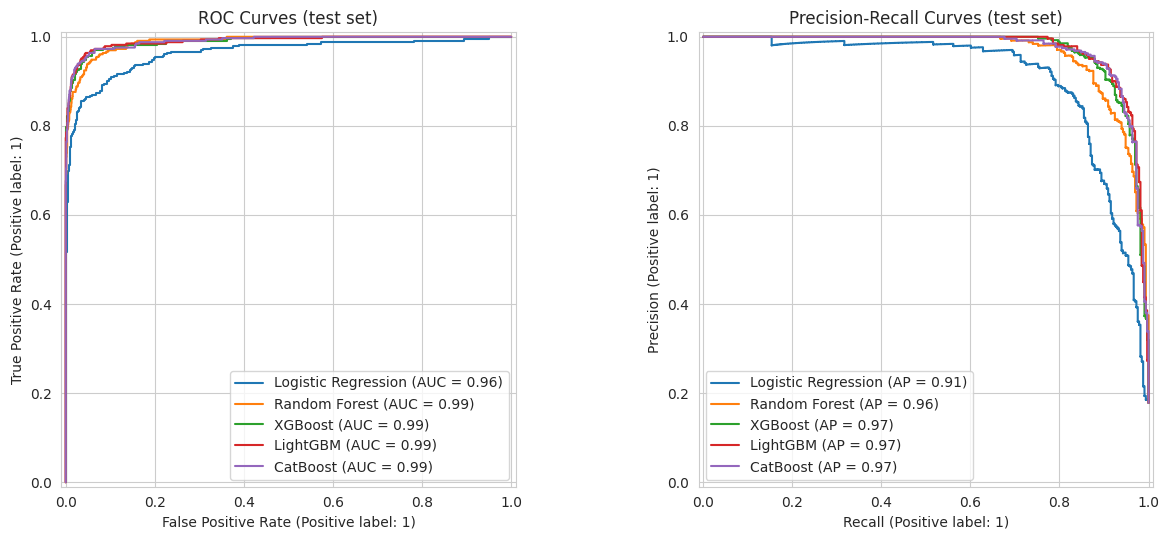

In [12]:
# ROC/Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, p in proba_test.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=name, ax=axes[1])
axes[0].set_title("ROC Curves (test set)")
axes[1].set_title("Precision-Recall Curves (test set)")
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=130)
plt.show()

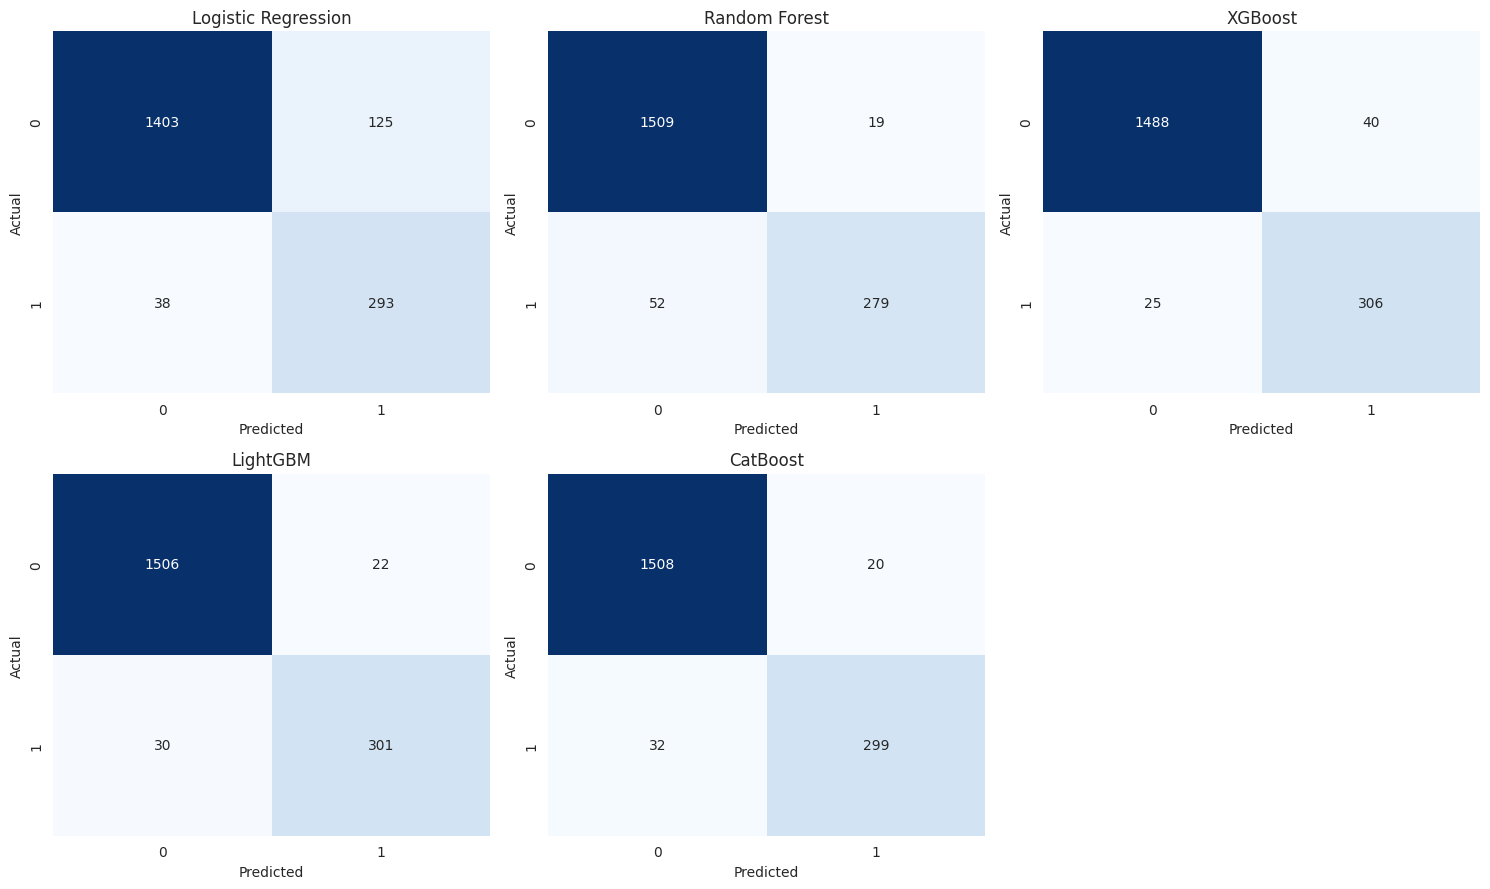

In [13]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, model) in zip(axes.flat, fitted_models.items()):
    cm = confusion_matrix(y_test, (proba_test[name] >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=130)
plt.show()

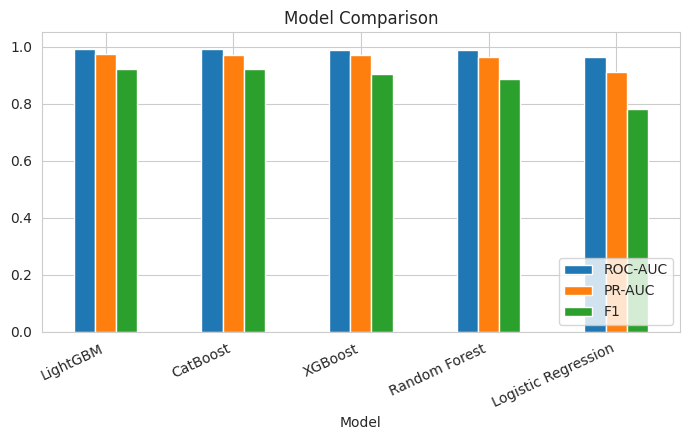

In [14]:
# Metric bar chart
fig, ax = plt.subplots(figsize=(7, 4.5))
comparison_df.set_index("Model")[["ROC-AUC", "PR-AUC", "F1"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("model_comparison_bars.png", dpi=130)
plt.show()

### Feature importance (best tree-based model)

A quick sanity check: do the top features make domain sense for fraud detection?

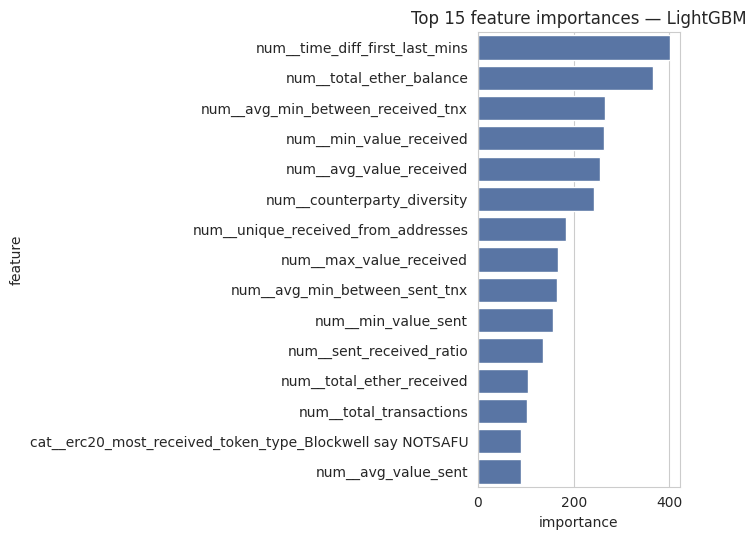

In [15]:
# Feature importance (best non-linear model, if applicable)
tree_models = {k: v for k, v in fitted_models.items() if k != "Logistic Regression"}
best_tree_name = comparison_df[comparison_df["Model"].isin(tree_models)].iloc[0]["Model"]
best_tree_model = fitted_models[best_tree_name]

feature_names = best_tree_model.named_steps["pre"].get_feature_names_out()
importances = best_tree_model.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, color="#4C72B0")
ax.set_title(f"Top 15 feature importances — {best_tree_name}")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130)
plt.show()

## 11. Best model selection

We rank by **test-set PR-AUC** as the primary metric (most informative under this class imbalance), with ROC-AUC and F1 as corroborating signals. The winner is saved as the project's final model.

In [16]:
# Select best model
best_model_name = comparison_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
print(comparison_df[comparison_df["Model"] == best_model_name].to_string(index=False))
print()
print(classification_report(y_test, (proba_test[best_model_name] >= 0.5).astype(int), target_names=["Legit", "Fraud"]))

BEST MODEL: LightGBM
   Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC  CV PR-AUC (train)
LightGBM  0.972028   0.931889 0.909366 0.920489 0.990597 0.973875           0.967274

              precision    recall  f1-score   support

       Legit       0.98      0.99      0.98      1528
       Fraud       0.93      0.91      0.92       331

    accuracy                           0.97      1859
   macro avg       0.96      0.95      0.95      1859
weighted avg       0.97      0.97      0.97      1859



## 12. Save artifacts

The full fitted pipeline (preprocessing **and** classifier) is saved with `joblib` — this is the standard for scikit-learn-compatible pipelines and means a teammate can load one file and call `.predict()` / `.predict_proba()` directly on raw feature rows, no separate preprocessing step needed.

In [17]:
# Save best model + Comparison artifacts
joblib.dump(best_model, "model/ethereum_fraud_detector.joblib")
comparison_df.to_csv("model_comparison.csv", index=False)
gap_df.to_csv("overfitting_check.csv", index=False)

with open("classification_report_best_model.txt", "w") as f:
    f.write(f"Best model: {best_model_name}\n\n")
    f.write(classification_report(y_test, (proba_test[best_model_name] >= 0.5).astype(int), target_names=["Legit", "Fraud"]))

print("Saved:")
print("  best_model.joblib               — full fitted pipeline (preprocessing + classifier)")
print("  model_comparison.csv            — metric table for all 5 models")
print("  overfitting_check.csv           — train vs test PR-AUC gap")
print("  classification_report_best_model.txt")
print("  roc_pr_curves.png, confusion_matrices.png, model_comparison_bars.png, feature_importance.png")

Saved:
  best_model.joblib               — full fitted pipeline (preprocessing + classifier)
  model_comparison.csv            — metric table for all 5 models
  overfitting_check.csv           — train vs test PR-AUC gap
  classification_report_best_model.txt
  roc_pr_curves.png, confusion_matrices.png, model_comparison_bars.png, feature_importance.png


## Summary

- **Split:** stratified 80/20 train/test, with 5-fold stratified CV on the training set for tuning and reporting (chosen over a fixed three-way split given the dataset size).
- **Imbalance:** class weighting (`class_weight` / `scale_pos_weight` / `auto_class_weights`) — empirically on par with SMOTE here, simpler, and native to every model.
- **Pipelines:** each model is a single `sklearn` `Pipeline` (preprocessing → classifier), so scaling/encoding never leaks across folds.
- **Tuning:** `RandomizedSearchCV` per model, scored on PR-AUC.
- **Evaluation:** full metric suite + ROC/PR curves + confusion matrices + train/test overfitting gap.
- **Result:** the boosting models (LightGBM, CatBoost, XGBoost) all land within ~1 point of each other on PR-AUC and comfortably ahead of Random Forest and Logistic Regression; the best one is saved as `best_model.joblib` for the team to use downstream.